# Event Participation Prediction (Linear Regression)

In [16]:
# Importing Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

import pickle
import os

In [2]:
# Loading Dataset
participation_df = pd.read_csv("../data/participation_dataset.csv")
participation_df.head()

,eventId,category,location,startDate,startTime,maxVolunteers,requiredSkillId,attendance_count
0,26,Environment,Negombo Beach,2026-02-21,09:00:00,30,6,8
1,27,Community,Raddolugama Public Library,2026-02-21,15:00:00,20,0,6
2,28,Education,Alawathupitiya School,2026-02-21,19:00:00,8,1,0
3,29,Health,Raddolugama Primary School,2026-02-23,12:30:00,20,3,7
4,30,Community,Alawathupitiya School,2026-02-23,18:00:00,20,12,18


In [3]:
participation_df.drop("eventId", axis=1, inplace=True)

In [4]:
# Convert Date Features
participation_df['startDate'] = pd.to_datetime(participation_df['startDate'])

participation_df['year'] = participation_df['startDate'].dt.year
participation_df['month'] = participation_df['startDate'].dt.month
participation_df['day'] = participation_df['startDate'].dt.day
participation_df['day_of_week'] = participation_df['startDate'].dt.dayofweek

# Convert Time Features
participation_df['startTime'] = pd.to_datetime(
    participation_df['startTime'],
    format='%H:%M:%S'
)

participation_df['hour'] = participation_df['startTime'].dt.hour
participation_df['minute'] = participation_df['startTime'].dt.minute

In [5]:
# Dropping Original Date Columns
participation_df.drop(['startDate', 'startTime'], axis=1, inplace=True)

In [6]:
# Defining Features and Target
X = participation_df.drop("attendance_count", axis=1)
y = participation_df["attendance_count"]

In [7]:
# Categorical Columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Preprocessor (One Hot Encoding)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

C:\Users\Sasindi Weerarathne\AppData\Local\Temp\ipykernel_14568\2278522885.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


In [8]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Random Forest Regressor Model

In [9]:
participation_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        max_depth=7,
        min_samples_split=5,
        min_samples_leaf=3,
        random_state=42
    ))
])

In [10]:
participation_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [11]:
# Predict
y_pred = participation_model.predict(X_test)

In [12]:
# Evaluate Model
print("===== Event Participation Prediction Evaluation =====")

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score :", r2_score(y_test, y_pred))

===== Event Participation Prediction Evaluation =====
MAE : 1.6768489139490466
RMSE : 2.5874749931205625
R2 Score : 0.5622024263863141


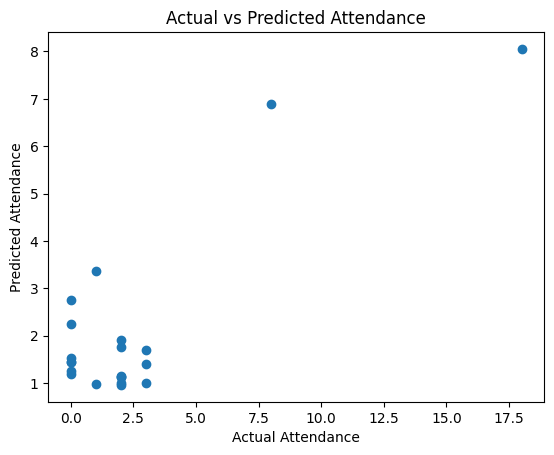

In [13]:
# Visualization
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Attendance")
plt.ylabel("Predicted Attendance")
plt.title("Actual vs Predicted Attendance")
plt.show()

In [14]:
print("Train R2:", participation_model.score(X_train, y_train))
print("Test R2:", participation_model.score(X_test, y_test))

Train R2: 0.769252953808997
Test R2: 0.5622024263863141


In [ ]:
# Saving the model
model_path = os.path.join(
    "..",
    "model",
    "participation_rf_model.pkl"
)

with open(model_path, "wb") as file:
    pickle.dump(participation_model, file)

print("Participation model saved successfully!")

Participation model saved successfully!
